In [3]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt

In [ ]:
https://restcountries.com/v3.1/all?fields=name,capital,currencies

In [ ]:
response = requests.get('https://restcountries.com/v3.1/all?fields=name,languages,un_member')
data = response.json()
data = pd.DataFrame.from_records(data)
data

In [ ]:
response = requests.get('https://restcountries.com/v3.1/all?fields=name,unMember,languages').text
data = json.loads(response)
data = pd.concat((pd.json_normalize(d) for d in data))
data = data[['unMember','name.common']]
data = data.reset_index(drop=True)
data

In [8]:
response = requests.get('https://restcountries.com/v3.1/all?fields=languages').text
lang = json.loads(response)
lang = pd.concat((pd.json_normalize(d['languages']) for d in lang), axis=0)
cols = []
for i in lang.columns:
    cols.append(i)
for i in cols:
    lang['cat'].fillna(lang[i],inplace=True)
lang = lang[['cat']]
lang = lang.reset_index(drop=True)
lang

,cat
0,Catalan
1,English
2,Serbian
3,English
4,Russian
...,...
245,English
246,English
247,Spanish
248,Arabic


In [ ]:
pd.merge(data, lang, left_index=True, right_index=True)

In [4]:
def fetch_countries_data():
    response = requests.get('https://restcountries.com/v3.1/all?fields=name,unMember,languages').text
    data = json.loads(response)
    data = pd.concat((pd.json_normalize(d) for d in data))
    data = data[['unMember','name.common']]
    data = data.reset_index(drop=True)
    data

    response = requests.get('https://restcountries.com/v3.1/all?fields=languages').text
    lang = json.loads(response)
    lang = pd.concat((pd.json_normalize(d['languages']) for d in lang), axis=0)
    cols = []
    for i in lang.columns:
        cols.append(i)
    for i in cols:
        lang['cat'].fillna(lang[i],inplace=True)
    lang = lang[['cat']]
    lang = lang.reset_index(drop=True)
    lang.rename(columns={'cat': 'languages'}, inplace=True)
    data = pd.merge(data, lang, left_index=True, right_index=True)
    
    return data

In [5]:
data = fetch_countries_data()

In [6]:
data

,unMember,name.common,languages
0,True,Andorra,Catalan
1,True,Trinidad and Tobago,English
2,True,Serbia,Serbian
3,True,United Kingdom,English
4,True,Russia,Russian
...,...,...,...
245,False,British Virgin Islands,English
246,False,Guernsey,English
247,True,Guatemala,Spanish
248,True,Syria,Arabic


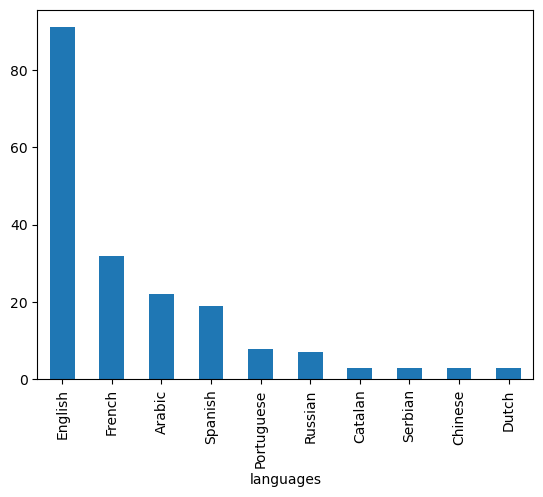

In [7]:
def draw_languages(data):
    fig, ax = plt.subplots()
    data['languages'].value_counts().iloc[:10].plot(ax=ax, kind='bar')
    

draw_languages(data)

In [ ]:
def draw_un_members():
    fig, ax = plt.subplots()
    data['unMember'].value_counts().plot(ax=ax, kind='bar')

draw_un_members()

In [ ]:
data.to_csv('data', index=False)

In [ ]:
import matplotlib.pyplot as plt